Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

The image is a 396 x 396 x 3 centre crop of scikit-learn's sample `flower.jpg`, saved as a lossless PNG. Each pixel is stored as 3 colour values (R, G, B) of 8 bits each, so the image can use up to 2²⁴ ≈ 16.7 million colours. K-Means compresses it by grouping all pixels into K colours and storing only a K-colour palette plus a small palette index for each pixel.

In [2]:
image = np.array(Image.open('06-kmeans-image-task-2.png'))
print("Image shape:", image.shape)
print("Unique colours:", len(np.unique(image.reshape(-1, 3), axis=0)))

Image shape: (396, 396, 3)
Unique colours: 56775


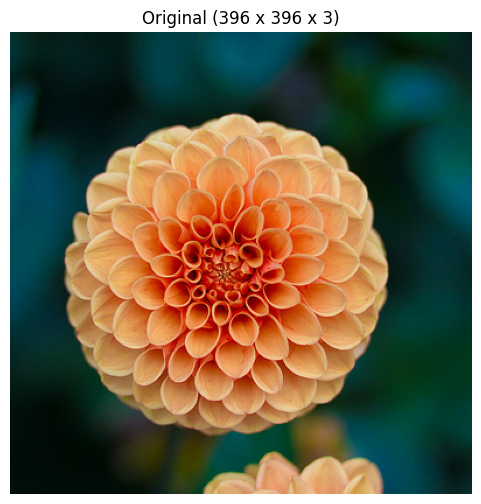

In [3]:
plt.figure(figsize=(6, 6))
plt.imshow(image); plt.axis('off'); plt.title('Original (396 x 396 x 3)')
plt.show()

In [4]:
pixels = image.reshape(-1, 3) / 255.0
print("Pixels as data points:", pixels.shape)

Pixels as data points: (156816, 3)


In [5]:
K = 16
model = KMeans(n_clusters=K, n_init=4, random_state=42)
labels = model.fit_predict(pixels)
palette = model.cluster_centers_

In [6]:
compressed = (palette[labels].reshape(image.shape) * 255).astype(np.uint8)

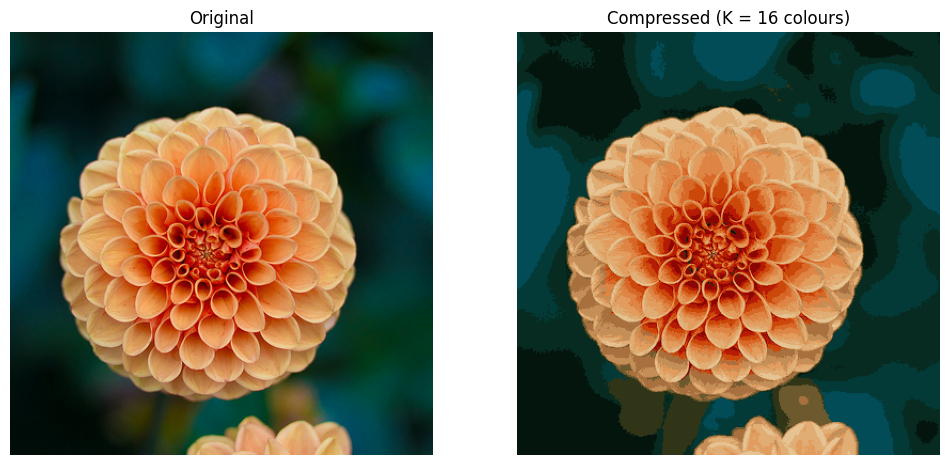

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image); axes[0].set_title('Original')
axes[1].imshow(compressed); axes[1].set_title(f'Compressed (K = {K} colours)')
for ax in axes: ax.axis('off')
plt.show()

In [8]:
h, w, _ = image.shape
original_bits = h * w * 24
compressed_bits = h * w * int(np.ceil(np.log2(K))) + K * 24

print("Compression Summary")
print("---------------------------")
print(f"Original size:   {original_bits:,} bits ({original_bits / 8 / 1024:.1f} KB)")
print(f"Compressed size: {compressed_bits:,} bits ({compressed_bits / 8 / 1024:.1f} KB)")
print(f"Compression ratio: {original_bits / compressed_bits:.2f}x")

Compression Summary
---------------------------
Original size:   3,763,584 bits (459.4 KB)
Compressed size: 627,648 bits (76.6 KB)
Compression ratio: 6.00x


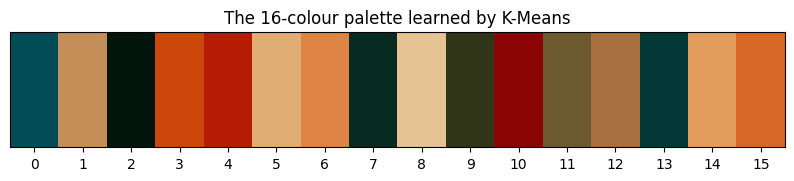

In [9]:
plt.figure(figsize=(10, 1.5))
plt.imshow(palette.reshape(1, K, 3), aspect='auto')
plt.yticks([]); plt.xticks(range(K)); plt.title(f'The {K}-colour palette learned by K-Means')
plt.show()

Comparing different values of K: fewer colours give a smaller image but lose more detail.

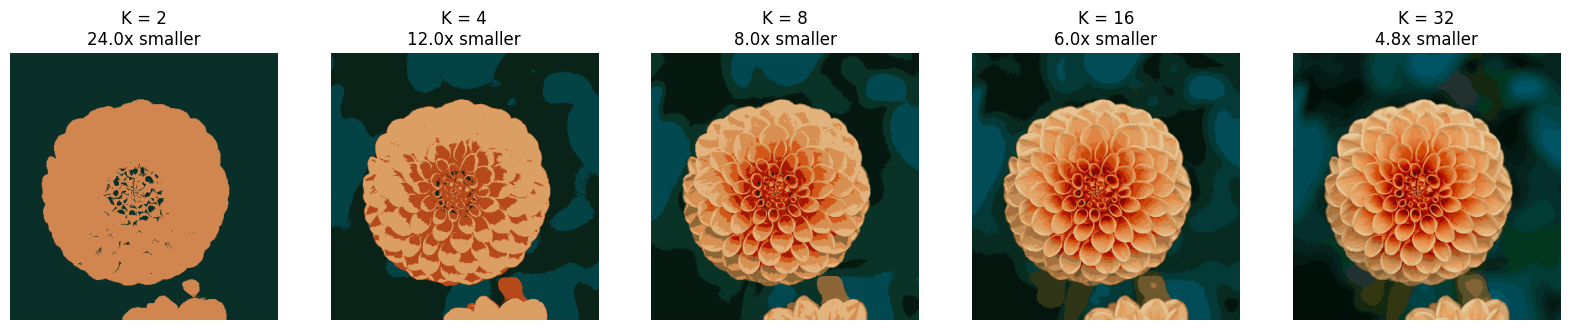

In [10]:
ks = [2, 4, 8, 16, 32]
fig, axes = plt.subplots(1, len(ks), figsize=(20, 4.5))
for ax, k in zip(axes, ks):
    km = KMeans(n_clusters=k, n_init=4, random_state=42).fit(pixels)
    img_k = km.cluster_centers_[km.labels_].reshape(image.shape)
    bits = h * w * int(np.ceil(np.log2(k))) + k * 24
    ax.imshow(img_k); ax.axis('off')
    ax.set_title(f"K = {k}\n{original_bits / bits:.1f}x smaller")
plt.show()